In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# List the contents of the root directory of your Google Drive
print(os.listdir('/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/'))

['data_final_sort_v2.jsonl', 'generate_training_query', 'data_train_v2.pkl', 'cosine_results_v2_model_bkai.csv', 'cosine_results_v2_model_e5.csv', 'bge_rerank_scored.csv', 'splits', 'data_filtered_v2.pkl']


In [3]:
# import os
# import pickle
# from sklearn.model_selection import train_test_split

# # ================================
# # 1) ĐƯỜNG DẪN TỆP GỐC
# # ================================
# data_path = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/data_filtered_v2.pkl"

# # ================================
# # 2) ĐƯỜNG DẪN LƯU SPLIT
# # ================================
# split_dir = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/splits"
# os.makedirs(split_dir, exist_ok=True)

# train_out = os.path.join(split_dir, "train_pairs_v2.pkl")
# val_out   = os.path.join(split_dir, "val_pairs_v2.pkl")
# test_out  = os.path.join(split_dir, "test_pairs_v2.pkl")

# # ================================
# # 3) TẢI DỮ LIỆU
# # ================================
# with open(data_path, "rb") as f:
#     data= pickle.load(f)

# print("Tổng số mẫu:", len(data))

# # ================================
# # 4) CHIA TRAIN / VAL / TEST 80–10–10
# # ================================
# train_pairs, temp_pairs = train_test_split(
#     data, test_size=0.2, random_state=42
# )

# val_pairs, test_pairs = train_test_split(
#     temp_pairs, test_size=0.5, random_state=42
# )

# print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

# # ================================
# # 5) LƯU LẠI 3 TỆP
# # ================================
# with open(train_out, "wb") as f:
#     pickle.dump(train_pairs, f)

# with open(val_out, "wb") as f:
#     pickle.dump(val_pairs, f)

# with open(test_out, "wb") as f:
#     pickle.dump(test_pairs, f)

# print("✓ Đã lưu xong các tệp:")
# print("  -", train_out)
# print("  -", val_out)
# print("  -", test_out)


In [4]:
# Tập dữ liệu
train_pairs = '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/splits/train_pairs_v2.pkl'
val_pairs = '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/splits/val_pairs_v2.pkl'
test_pairs = '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/splits/test_pairs_v2.pkl'

In [5]:
# ----------------------------
# 1) HÀM LOAD DỮ LIỆU CẶP (query - positive)
# ----------------------------
from pathlib import Path
import pickle
from typing import List
from sentence_transformers import InputExample

def load_pairs(pkl_path: Path, preview: int = 2) -> List[InputExample]:
    """
    Đọc file .pkl chứa danh sách InputExample (mỗi mẫu gồm 2 trường: query và passage).
    - pkl_path: đường dẫn tới file .pkl chứa dữ liệu.
    - preview: số lượng mẫu đầu tiên sẽ được in ra để kiểm tra.
    Trả về: list các InputExample (định dạng chuẩn cho SentenceTransformers).
    """

    # Mở file pickle và load dữ liệu gốc (list object)
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    pairs = []     # danh sách lưu các cặp hợp lệ (query–positive)
    i = 0          # đếm số mẫu đã đọc

    for ex in data:
        # Bỏ qua nếu không phải kiểu InputExample (phòng trường hợp file lẫn object khác)
        if not isinstance(ex, InputExample):
            continue

        texts = ex.texts  # texts là list chứa các chuỗi, vd: ["query", "positive"]

        # Chỉ lấy các mẫu có đúng 2 trường (query & positive)
        if len(texts) == 2:
            q = f"{texts[0].strip()}"   # câu hỏi / truy vấn
            p = f"{texts[1].strip()}"   # đoạn văn bản trả lời tương ứng
            # Tạo một đối tượng InputExample mới (giữ nguyên format)
            pairs.append(InputExample(texts=[texts[0], texts[1]]))
        else:
            continue  # bỏ qua nếu mẫu không hợp lệ (vd. 1 hoặc 3+ trường)

        # Hiển thị trước một vài mẫu đầu để kiểm tra
        if i < preview:
            print(f"\n🔹 Mẫu {i+1}:")
            print(f"{q}")
            print(f"{p[:150]}")  # chỉ in 150 ký tự đầu của passage cho gọn

        i += 1

    #  Lưu ý: dòng gốc của bạn có bug vì gọi 'triplets' (chưa định nghĩa)
    # → phải sửa lại thành 'pairs'
    print(f"\n Tổng số mẫu hợp lệ: {len(pairs)}")

    return pairs

# pairs: List[InputExample] = load_pairs(data_path)

In [6]:
train_pairs = load_pairs(train_pairs)
val_pairs = load_pairs(val_pairs )
test_pairs = load_pairs(test_pairs)
print(" Train pairs:", len(train_pairs))
print(" Val pairs:", len(val_pairs))
print(" Test pairs:", len(test_pairs))


🔹 Mẫu 1:
query: Khu vực lối vào cửa có những phòng chức năng nào?
passage: Khu vực lối vào cửa có phòng tiếp tân kết hợp với nhiều phòng chức năng khác. Không gian tầng trệt của Dinh Bảo Đại III. Ảnh: tiendatt120799 

🔹 Mẫu 2:
query: Có điểm tham quan nào đặc biệt ở Tả Phìn không?
passage: Tả Phìn chính là quê hương của lá thuốc tắm Dao Đỏ nổi tiếng nhiều năm nay. Vì thế đến đây du khách có cơ hội tắm lá thuốc tươi, mua đồ thổ c

 Tổng số mẫu hợp lệ: 52431

🔹 Mẫu 1:
query: Món ăn nào được chế biến từ trứng kiến mà tác giả thích nhất?
passage: Ẩm thực ở Bắc Giang. Lên Bắc Giang ăn đặc sản trứng kiến: Mùa này, nếu có dịp ghé thăm Bắc Giang và được chủ nhà thiết đãi những món ăn chế b

🔹 Mẫu 2:
query: Công suất phục vụ của Riyadh Metro có thể đạt bao nhiêu hành khách mỗi ngày?
passage: Điểm đến ở An Giang. Đón chờ top 4 công trình du lịch năm 2025 được mong đợi nhất: Top 4 công trình du lịch năm 2025 sau đây được thế giới mo

 Tổng số mẫu hợp lệ: 6554

🔹 Mẫu 1:
query: Lễ hội chùa Bà được

In [7]:
from __future__ import annotations

import heapq
import json
import logging
import os
from typing import TYPE_CHECKING, Callable

import numpy as np
import torch
from torch import Tensor
from tqdm import trange

from sentence_transformers.evaluation.SentenceEvaluator import SentenceEvaluator
from sentence_transformers.similarity_functions import SimilarityFunction

if TYPE_CHECKING:
    from sentence_transformers.SentenceTransformer import SentenceTransformer

logger = logging.getLogger(__name__)


class InformationRetrievalEvaluator(SentenceEvaluator):
    """
    Lớp đánh giá hiệu năng của mô hình cho bài toán Truy vấn thông tin (Information Retrieval - IR).

    Cơ chế hoạt động:
    1. Nhận vào tập câu hỏi (queries) và tập tài liệu (corpus).
    2. Mã hóa (embedding) queries và corpus thành vector.
    3. Tính độ tương đồng (similarity) giữa vector câu hỏi và vector tài liệu.
    4. Tìm ra top-k tài liệu liên quan nhất cho mỗi câu hỏi.
    5. So sánh với nhãn đúng (relevant_docs) để tính các chỉ số: MRR, NDCG, MAP, Accuracy, Precision, Recall.
    """

    def __init__(
        self,
        queries: dict[str, str],  # Dict: {query_id: nội dung query}
        corpus: dict[str, str],   # Dict: {doc_id: nội dung document}
        relevant_docs: dict[str, set[str]],  # Dict: {query_id: set các doc_id đúng/liên quan}
        corpus_chunk_size: int = 50000,      # Kích thước chunk khi xử lý corpus để tránh tràn RAM
        mrr_at_k: list[int] = [10],          # Tính Mean Reciprocal Rank tại top k
        ndcg_at_k: list[int] = [10],         # Tính Normalized Discounted Cumulative Gain tại top k
        accuracy_at_k: list[int] = [1, 3, 5, 10],      # Tỷ lệ có ít nhất 1 kết quả đúng trong top k
        precision_recall_at_k: list[int] = [1, 3, 5, 10], # Precision và Recall tại top k
        map_at_k: list[int] = [100],         # Mean Average Precision
        show_progress_bar: bool = False,
        batch_size: int = 32,
        name: str = "",
        write_csv: bool = True,              # Có ghi kết quả ra file CSV không
        truncate_dim: int | None = None,     # Cắt giảm chiều vector (nếu cần test hiệu năng chiều thấp)
        score_functions: dict[str, Callable[[Tensor, Tensor], Tensor]] | None = None, # Hàm tính điểm (Cosine, Dot product...)
        main_score_function: str | SimilarityFunction | None = None, # Hàm chính để so sánh
        query_prompt: str | None = None,     # Prompt thêm vào trước query (dùng cho các model LLM/Instruct)
        query_prompt_name: str | None = None,
        corpus_prompt: str | None = None,    # Prompt thêm vào trước document
        corpus_prompt_name: str | None = None,
        write_predictions: bool = False,     # Ghi chi tiết kết quả dự đoán ra file JSONL
    ) -> None:
        super().__init__()

        # --- BƯỚC 1: LỌC DỮ LIỆU ---
        # Chỉ giữ lại các query ID mà thực sự có đáp án trong tập relevant_docs.
        # Nếu query không có đáp án nào thì không thể đánh giá được.
        self.queries_ids = []
        for qid in queries:
            if qid in relevant_docs and len(relevant_docs[qid]) > 0:
                self.queries_ids.append(qid)

        # Tạo danh sách nội dung query tương ứng với ID đã lọc
        self.queries = [queries[qid] for qid in self.queries_ids]

        # Chuyển corpus từ dict sang list để có thể truy cập bằng index số học (cần cho việc chunking)
        self.corpus_ids = list(corpus.keys())
        self.corpus = [corpus[cid] for cid in self.corpus_ids]

        # Lưu các tham số cấu hình
        self.query_prompt = query_prompt
        self.query_prompt_name = query_prompt_name
        self.corpus_prompt = corpus_prompt
        self.corpus_prompt_name = corpus_prompt_name

        self.relevant_docs = relevant_docs
        self.corpus_chunk_size = corpus_chunk_size
        self.mrr_at_k = mrr_at_k
        self.ndcg_at_k = ndcg_at_k
        self.accuracy_at_k = accuracy_at_k
        self.precision_recall_at_k = precision_recall_at_k
        self.map_at_k = map_at_k

        self.show_progress_bar = show_progress_bar
        self.batch_size = batch_size
        self.name = name
        self.write_csv = write_csv
        self.score_functions = score_functions

        # Nếu user truyền hàm tính điểm vào thì lấy tên, không thì để trống (sẽ lấy mặc định từ model sau)
        self.score_function_names = sorted(list(self.score_functions.keys())) if score_functions else []
        self.main_score_function = SimilarityFunction(main_score_function) if main_score_function else None
        self.truncate_dim = truncate_dim

        if name:
            name = "_" + name

        # Thiết lập tên file output
        self.csv_file: str = "Information-Retrieval_evaluation" + name + "_results.csv"
        self.csv_headers = ["epoch", "steps"]

        # Tạo header cho file CSV (VD: cos_sim-Accuracy@10, dot-MRR@10...)
        self._append_csv_headers(self.score_function_names)

        self.write_predictions = write_predictions
        if self.write_predictions:
            self.predictions_file = "Information-Retrieval_evaluation" + name + "_predictions.jsonl"

    def _append_csv_headers(self, score_function_names):
        """Tạo tên cột cho file CSV ứng với từng metric và từng mức k."""
        for score_name in score_function_names:
            for k in self.accuracy_at_k:
                self.csv_headers.append(f"{score_name}-Accuracy@{k}")

            for k in self.precision_recall_at_k:
                self.csv_headers.append(f"{score_name}-Precision@{k}")
                self.csv_headers.append(f"{score_name}-Recall@{k}")

            for k in self.mrr_at_k:
                self.csv_headers.append(f"{score_name}-MRR@{k}")

            for k in self.ndcg_at_k:
                self.csv_headers.append(f"{score_name}-NDCG@{k}")

            for k in self.map_at_k:
                self.csv_headers.append(f"{score_name}-MAP@{k}")

    def __call__(
        self,
        model: SentenceTransformer,
        output_path: str | None = None,
        epoch: int = -1,
        steps: int = -1,
        *args,
        **kwargs,
    ) -> dict[str, float]:
        """
        Hàm này được gọi tự động khi chạy quá trình evaluation (VD: trong vòng lặp training).
        Nó đóng vai trò 'nhạc trưởng' điều phối quy trình đánh giá.
        """
        if epoch != -1:
            if steps == -1:
                out_txt = f" after epoch {epoch}"
            else:
                out_txt = f" in epoch {epoch} after {steps} steps"
        else:
            out_txt = ""
        if self.truncate_dim is not None:
            out_txt += f" (truncated to {self.truncate_dim})"

        logger.info(f"Information Retrieval Evaluation of the model on the {self.name} dataset{out_txt}:")

        # Nếu lúc init chưa có score function, lấy mặc định của model (thường là Cosine Similarity)
        if self.score_functions is None:
            self.score_functions = {model.similarity_fn_name: model.similarity}
            self.score_function_names = [model.similarity_fn_name]
            self._append_csv_headers(self.score_function_names)

        # --- TÍNH TOÁN METRICS (GỌI HÀM CON) ---
        scores = self.compute_metrices(model, output_path=output_path, *args, **kwargs)

        # --- GHI FILE CSV ---
        if output_path is not None and self.write_csv:
            os.makedirs(output_path, exist_ok=True)
            csv_path = os.path.join(output_path, self.csv_file)

            # Nếu file chưa tồn tại, ghi header trước
            if not os.path.isfile(csv_path):
                fOut = open(csv_path, mode="w", encoding="utf-8")
                fOut.write(",".join(self.csv_headers))
                fOut.write("\n")
            else:
                fOut = open(csv_path, mode="a", encoding="utf-8")

            # Ghi dữ liệu dòng hiện tại
            output_data = [epoch, steps]
            for name in self.score_function_names:
                for k in self.accuracy_at_k:
                    output_data.append(scores[name]["accuracy@k"][k])

                for k in self.precision_recall_at_k:
                    output_data.append(scores[name]["precision@k"][k])
                    output_data.append(scores[name]["recall@k"][k])

                for k in self.mrr_at_k:
                    output_data.append(scores[name]["mrr@k"][k])

                for k in self.ndcg_at_k:
                    output_data.append(scores[name]["ndcg@k"][k])

                for k in self.map_at_k:
                    output_data.append(scores[name]["map@k"][k])

            fOut.write(",".join(map(str, output_data)))
            fOut.write("\n")
            fOut.close()

        # --- XÁC ĐỊNH PRIMARY METRIC ---
        # Dùng để quyết định xem model checkpoint này có phải là tốt nhất không.
        # Mặc định ưu tiên NDCG cao nhất.
        if not self.primary_metric:
            if self.main_score_function is None:
                score_function = max(
                    [(name, scores[name]["ndcg@k"][max(self.ndcg_at_k)]) for name in self.score_function_names],
                    key=lambda x: x[1],
                )[0]
                self.primary_metric = f"{score_function}_ndcg@{max(self.ndcg_at_k)}"
            else:
                self.primary_metric = f"{self.main_score_function.value}_ndcg@{max(self.ndcg_at_k)}"

        # Làm phẳng dict kết quả để trả về (thuận tiện cho việc logging của Trainer)
        metrics = {
            f"{score_function}_{metric_name.replace('@k', '@' + str(k))}": value
            for score_function, values_dict in scores.items()
            for metric_name, values in values_dict.items()
            for k, value in values.items()
        }
        metrics = self.prefix_name_to_metrics(metrics, self.name)
        self.store_metrics_in_model_card_data(model, metrics, epoch, steps)
        return metrics

    def compute_metrices(
        self,
        model: SentenceTransformer,
        corpus_model=None,
        corpus_embeddings: Tensor | None = None,
        output_path: str | None = None,
    ) -> dict[str, float]:
        """
        Đây là trái tim của thuật toán đánh giá.
        Quy trình:
        1. Encode Query.
        2. Encode Corpus (theo từng chunk nhỏ).
        3. Tính điểm similarity giữa Query và Chunk.
        4. Dùng Heap để duy trì danh sách Top-K văn bản tốt nhất (giúp tiết kiệm bộ nhớ).
        """
        if corpus_model is None:
            corpus_model = model

        # Xác định k lớn nhất cần tìm (để giới hạn kích thước heap)
        max_k = max(
            max(self.mrr_at_k),
            max(self.ndcg_at_k),
            max(self.accuracy_at_k),
            max(self.precision_recall_at_k),
            max(self.map_at_k),
        )

        # 1. Encode toàn bộ queries
        query_embeddings = self.embed_inputs(
            model,
            self.queries,
            encode_fn_name="query",
            prompt_name=self.query_prompt_name,
            prompt=self.query_prompt,
        )

        # Khởi tạo list chứa kết quả cho từng score function.
        # queries_result_list[name][i] sẽ là một Heap chứa top-k kết quả cho query thứ i
        queries_result_list = {}
        for name in self.score_functions:
            queries_result_list[name] = [[] for _ in range(len(query_embeddings))]

        # 2. Xử lý Corpus theo từng Chunk (để không bị Out of Memory với corpus lớn)
        for corpus_start_idx in trange(
            0, len(self.corpus), self.corpus_chunk_size, desc="Corpus Chunks", disable=not self.show_progress_bar
        ):
            corpus_end_idx = min(corpus_start_idx + self.corpus_chunk_size, len(self.corpus))

            # Encode chunk corpus hiện tại (nếu chưa có embeddings truyền vào sẵn)
            if corpus_embeddings is None:
                sub_corpus_embeddings = self.embed_inputs(
                    corpus_model,
                    self.corpus[corpus_start_idx:corpus_end_idx],
                    encode_fn_name="document",
                    prompt_name=self.corpus_prompt_name,
                    prompt=self.corpus_prompt,
                )
            else:
                sub_corpus_embeddings = corpus_embeddings[corpus_start_idx:corpus_end_idx]

            # 3. Tính điểm Similarity và cập nhật Heap
            for name, score_function in self.score_functions.items():
                # Tính ma trận similarity: [num_queries x corpus_chunk_size]
                pair_scores = score_function(query_embeddings, sub_corpus_embeddings)

                # Lấy Top-k trong chunk hiện tại bằng torch (rất nhanh trên GPU)
                pair_scores_top_k_values, pair_scores_top_k_idx = torch.topk(
                    pair_scores, min(max_k, len(pair_scores[0])), dim=1, largest=True, sorted=False
                )
                pair_scores_top_k_values = pair_scores_top_k_values.cpu().tolist()
                pair_scores_top_k_idx = pair_scores_top_k_idx.cpu().tolist()

                # Cập nhật Global Heap cho từng query
                for query_itr in range(len(query_embeddings)):
                    for sub_corpus_id, score in zip(
                        pair_scores_top_k_idx[query_itr], pair_scores_top_k_values[query_itr]
                    ):
                        # Quy đổi từ index trong chunk về index toàn cục của corpus
                        corpus_id = self.corpus_ids[corpus_start_idx + sub_corpus_id]

                        # Logic Heap:
                        # - Nếu chưa đủ max_k phần tử: cứ thêm vào.
                        # - Nếu đã đủ: đẩy phần tử mới vào và loại bỏ phần tử bé nhất (heappushpop).
                        # Lưu ý: heapq trong Python là min-heap, nên nó sẽ loại phần tử có score thấp nhất, giữ lại các score cao.
                        if len(queries_result_list[name][query_itr]) < max_k:
                            heapq.heappush(queries_result_list[name][query_itr], (score, corpus_id))
                        else:
                            heapq.heappushpop(queries_result_list[name][query_itr], (score, corpus_id))

        # Chuyển đổi định dạng từ tuple (score, id) sang dict để dễ đọc ở bước sau
        for name in queries_result_list:
            for query_itr in range(len(queries_result_list[name])):
                for doc_itr in range(len(queries_result_list[name][query_itr])):
                    score, corpus_id = queries_result_list[name][query_itr][doc_itr]
                    queries_result_list[name][query_itr][doc_itr] = {"corpus_id": corpus_id, "score": score}

        # 4. Ghi file Predictions (nếu được yêu cầu)
        if self.write_predictions and output_path is not None:
            for name in queries_result_list:
                base_filename = self.predictions_file.replace(".jsonl", f"_{name}.jsonl")
                json_path = os.path.join(output_path, base_filename)
                mode = "w"

                with open(json_path, mode=mode, encoding="utf-8") as fOut:
                    for query_itr in range(len(queries_result_list[name])):
                        query_id = self.queries_ids[query_itr]
                        query_text = self.queries[query_itr]
                        results = queries_result_list[name][query_itr]

                        # Heap không đảm bảo thứ tự sort, cần sort lại giảm dần trước khi ghi
                        results = sorted(results, key=lambda x: x["score"], reverse=True)

                        prediction = {
                            "query_id": query_id,
                            "query": query_text,
                            "results": results,
                        }
                        fOut.write(json.dumps(prediction) + "\n")

        logger.info(f"Queries: {len(self.queries)}")
        logger.info(f"Corpus: {len(self.corpus)}\n")

        # 5. Tính toán các chỉ số (Accuracy, MRR, NDCG...) dựa trên danh sách kết quả đã tìm được
        scores = {name: self.compute_metrics(queries_result_list[name]) for name in self.score_functions}

        # In log
        for name in self.score_function_names:
            logger.info(f"Score-Function: {name}")
            self.output_scores(scores[name])

        return scores

    def embed_inputs(
        self,
        model: SentenceTransformer,
        sentences: str | list[str] | np.ndarray,
        encode_fn_name: str | None = None,
        prompt_name: str | None = None,
        prompt: str | None = None,
        **kwargs,
    ) -> np.ndarray:
        """
        Hàm bao (wrapper) để gọi chức năng encode của model.
        Hỗ trợ việc chọn hàm encode (encode_query vs encode_document) cho các model bất đối xứng.
        """
        if encode_fn_name is None:
            encode_fn = model.encode
        elif encode_fn_name == "query":
            encode_fn = model.encode_query
        elif encode_fn_name == "document":
            encode_fn = model.encode_document
        return encode_fn(
            sentences,
            prompt_name=prompt_name,
            prompt=prompt,
            batch_size=self.batch_size,
            show_progress_bar=self.show_progress_bar,
            convert_to_tensor=True,  # Quan trọng: trả về Tensor để tính toán trên GPU
            truncate_dim=self.truncate_dim,
            **kwargs,
        )

    def compute_metrics(self, queries_result_list: list[object]):
        """
        Hàm tính toán thống kê (Math logic).
        Input: Danh sách kết quả dự đoán của model.
        Output: Dictionary các chỉ số Accuracy, Precision, Recall, MRR, NDCG, MAP.
        """
        # Khởi tạo các biến tích lũy
        num_hits_at_k = {k: 0 for k in self.accuracy_at_k}
        precisions_at_k = {k: [] for k in self.precision_recall_at_k}
        recall_at_k = {k: [] for k in self.precision_recall_at_k}
        MRR = {k: 0 for k in self.mrr_at_k}
        ndcg = {k: [] for k in self.ndcg_at_k}
        AveP_at_k = {k: [] for k in self.map_at_k}

        # Duyệt qua từng query
        for query_itr in range(len(queries_result_list)):
            query_id = self.queries_ids[query_itr]

            # Sắp xếp kết quả từ cao xuống thấp
            top_hits = sorted(queries_result_list[query_itr], key=lambda x: x["score"], reverse=True)
            query_relevant_docs = self.relevant_docs[query_id]

            # --- Accuracy@k ---
            # Chỉ cần 1 tài liệu đúng nằm trong top k là được tính 1 điểm.
            for k_val in self.accuracy_at_k:
                for hit in top_hits[0:k_val]:
                    if hit["corpus_id"] in query_relevant_docs:
                        num_hits_at_k[k_val] += 1
                        break

            # --- Precision@k & Recall@k ---
            for k_val in self.precision_recall_at_k:
                num_correct = 0
                for hit in top_hits[0:k_val]:
                    if hit["corpus_id"] in query_relevant_docs:
                        num_correct += 1

                # Precision: Số câu đúng / Tổng số câu đã lấy (k)
                precisions_at_k[k_val].append(num_correct / k_val)
                # Recall: Số câu đúng tìm được / Tổng số câu đúng thực tế trong dữ liệu
                recall_at_k[k_val].append(num_correct / len(query_relevant_docs))

            # --- MRR@k (Mean Reciprocal Rank) ---
            # Quan tâm đến vị trí (rank) của kết quả đúng ĐẦU TIÊN.
            # Ví dụ: đúng ở vị trí 1 -> 1/1, vị trí 2 -> 1/2...
            for k_val in self.mrr_at_k:
                for rank, hit in enumerate(top_hits[0:k_val]):
                    if hit["corpus_id"] in query_relevant_docs:
                        MRR[k_val] += 1.0 / (rank + 1)
                        break

            # --- NDCG@k (Normalized Discounted Cumulative Gain) ---
            # Quan tâm đến cả thứ tự xếp hạng của nhiều kết quả đúng.
            # Kết quả đúng ở top đầu được đánh giá cao hơn nhiều so với ở dưới.
            for k_val in self.ndcg_at_k:
                predicted_relevance = [
                    1 if top_hit["corpus_id"] in query_relevant_docs else 0 for top_hit in top_hits[0:k_val]
                ]
                true_relevances = [1] * len(query_relevant_docs)

                ndcg_value = self.compute_dcg_at_k(predicted_relevance, k_val) / self.compute_dcg_at_k(
                    true_relevances, k_val
                )
                ndcg[k_val].append(ndcg_value)

            # --- MAP@k (Mean Average Precision) ---
            # Trung bình của Precision tại mỗi lần tìm thấy một tài liệu đúng.
            # Đo lường độ ổn định của việc tìm kiếm.
            for k_val in self.map_at_k:
                num_correct = 0
                sum_precisions = 0

                for rank, hit in enumerate(top_hits[0:k_val]):
                    if hit["corpus_id"] in query_relevant_docs:
                        num_correct += 1
                        sum_precisions += num_correct / (rank + 1)

                avg_precision = sum_precisions / min(k_val, len(query_relevant_docs))
                AveP_at_k[k_val].append(avg_precision)

        # Tính trung bình (Mean) cho tất cả queries
        for k in num_hits_at_k:
            num_hits_at_k[k] /= len(self.queries)

        for k in precisions_at_k:
            precisions_at_k[k] = np.mean(precisions_at_k[k])

        for k in recall_at_k:
            recall_at_k[k] = np.mean(recall_at_k[k])

        for k in ndcg:
            ndcg[k] = np.mean(ndcg[k])

        for k in MRR:
            MRR[k] /= len(self.queries)

        for k in AveP_at_k:
            AveP_at_k[k] = np.mean(AveP_at_k[k])

        return {
            "accuracy@k": num_hits_at_k,
            "precision@k": precisions_at_k,
            "recall@k": recall_at_k,
            "ndcg@k": ndcg,
            "mrr@k": MRR,
            "map@k": AveP_at_k,
        }

    def output_scores(self, scores):
        """In log kết quả."""
        for k in scores["accuracy@k"]:
            logger.info("Accuracy@{}: {:.2f}%".format(k, scores["accuracy@k"][k] * 100))

        for k in scores["precision@k"]:
            logger.info("Precision@{}: {:.2f}%".format(k, scores["precision@k"][k] * 100))

        for k in scores["recall@k"]:
            logger.info("Recall@{}: {:.2f}%".format(k, scores["recall@k"][k] * 100))

        for k in scores["mrr@k"]:
            logger.info("MRR@{}: {:.4f}".format(k, scores["mrr@k"][k]))

        for k in scores["ndcg@k"]:
            logger.info("NDCG@{}: {:.4f}".format(k, scores["ndcg@k"][k]))

        for k in scores["map@k"]:
            logger.info("MAP@{}: {:.4f}".format(k, scores["map@k"][k]))

    @staticmethod
    def compute_dcg_at_k(relevances, k):
        """
        Tính DCG (Discounted Cumulative Gain).
        Công thức: Sum(relevance / log2(rank + 1))
        """
        dcg = 0
        for i in range(min(len(relevances), k)):
            dcg += relevances[i] / np.log2(i + 2)  # +2 vì index i chạy từ 0
        return dcg

    def get_config_dict(self):
        """Lưu cấu hình evaluator để tái sử dụng hoặc ghi log."""
        config_dict = {}
        config_dict_candidate_keys = [
            "truncate_dim",
            "query_prompt",
            "query_prompt_name",
            "corpus_prompt",
            "corpus_prompt_name",
        ]
        for key in config_dict_candidate_keys:
            if getattr(self, key) is not None:
                config_dict[key] = getattr(self, key)
        return config_dict

In [8]:
# =====  Tạo queries / corpus / qrels =====
def ensure_prefix(s: str, kind: str) -> str:
    import re
    s = re.sub(fr"^{kind}:\s*{kind}:\s*", f"{kind}: ", s, flags=re.I)
    return s if s.lower().startswith(f"{kind}:") else f"{kind}: {s}"

def build_ir_inputs(pairs):
    queries, corpus, qrels = {}, {}, {}
    for i, ex in enumerate(pairs):
        if len(ex.texts) != 2:
            continue
        q = ensure_prefix(ex.texts[0].strip(), "query")
        p = ensure_prefix(ex.texts[1].strip(), "passage")
        qid, did = f"q{i}", f"d{i}"
        queries[qid] = q
        corpus[did] = p
        qrels[qid] = {did}
    return queries, corpus, qrels

queries, corpus, qrels = build_ir_inputs(test_pairs)

print(f"Queries: {len(queries)} | Corpus: {len(corpus)} | Qrels: {len(qrels)}")


Queries: 6554 | Corpus: 6554 | Qrels: 6554


**FINE TUNING MODEL sentence-transformers/all-mpnet-base-v2**

In [9]:
from sentence_transformers import SentenceTransformer

# ===== Load base model =====
BASE_MODEL_v2 = "sentence-transformers/all-mpnet-base-v2"
print("\n Đang tải model base...")
model_base_v2 = SentenceTransformer(BASE_MODEL_v2)

# ===== Tạo Evaluator (không ghi file) =====
ir_eval = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=qrels,
    mrr_at_k=[10],
    ndcg_at_k=[10],
    accuracy_at_k=[1, 3, 5, 10],
    precision_recall_at_k=[1, 3, 5, 10],
    map_at_k=[100],
    batch_size=64,
    show_progress_bar=True,
    name="tourism-test",
)

# ===== Chạy đánh giá (không cần output_path) =====
print("\n===== 🧭 BASE MODEL =====")
res_base = ir_eval(model_base_v2)  #  bỏ output_path

# In kết quả
print("===  Evaluation Results ===")
for metric, value in sorted(res_base.items()):
    print(f"{metric:25s}: {value:.4f}")



 Đang tải model base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [02:26<00:00, 146.78s/it]


===  Evaluation Results ===
tourism-test_cosine_accuracy@1: 0.0639
tourism-test_cosine_accuracy@10: 0.1823
tourism-test_cosine_accuracy@3: 0.1163
tourism-test_cosine_accuracy@5: 0.1440
tourism-test_cosine_map@100: 0.1041
tourism-test_cosine_mrr@10: 0.0978
tourism-test_cosine_ndcg@10: 0.1178
tourism-test_cosine_precision@1: 0.0639
tourism-test_cosine_precision@10: 0.0182
tourism-test_cosine_precision@3: 0.0388
tourism-test_cosine_precision@5: 0.0288
tourism-test_cosine_recall@1: 0.0639
tourism-test_cosine_recall@10: 0.1823
tourism-test_cosine_recall@3: 0.1163
tourism-test_cosine_recall@5: 0.1440


In [ ]:
# import os, math, torch
# from torch.utils.data import DataLoader
# from sentence_transformers import SentenceTransformer, InputExample, losses
# from sentence_transformers.evaluation import InformationRetrievalEvaluator

# # ===== 0) Cấu hình =====
# # Gợi ý cấu hình cho all-mpnet-base-v2:
# # - MAX_LEN: 256 (MPNet hoạt động tốt ở 256)
# # - BATCH_SIZE: 32 nếu đủ VRAM (T4 ~16GB vẫn ổn); nếu OOM, hạ xuống 16/8
# # - LR: 2e-5 (ổn định cho MNRL), có thể 3e-5 nếu dữ liệu rất sạch/lớn
# # - EPOCHS: 2–3 là hợp lý để tránh overfit
# # - WARMUP_RT: 0.1 (10% bước warmup)
# # - EVAL_EVERY: ~ mỗi 250–500 bước; hoặc 0 để tắt eval giữa chừng

# os.environ["WANDB_DISABLED"] = "true"
# os.environ["WANDB_SILENT"]   = "true"

# BASE_MODEL_MPNET_V2 = "sentence-transformers/all-mpnet-base-v2"
# OUTPUT_DIR_MPNET_V2 = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/train_model/mpnet-base-v2_fine_tuning_v2"

# BATCH_SIZE = 4
# MAX_LEN    = 512
# EPOCHS     = 8
# LR         = 2e-5
# WARMUP_RT  = 0.1
# EVAL_EVERY = 200
# USE_AMP    = True

# os.makedirs(OUTPUT_DIR_MPNET_V2, exist_ok=True)

# # ===== 1) Dữ liệu =====
# # Yêu cầu sẵn 3 lists: train_pairs, val_pairs, test_pairs
# # Mỗi phần tử là InputExample(texts=[query, positive])
# # Nếu dữ liệu của bạn đang theo format E5 ("query: ...", "passage: ..."), nên bỏ prefix:

# def strip_e5_prefix(s: str) -> str:
#     s = s.lstrip()
#     for p in ("query:", "passage:"):
#         if s.lower().startswith(p):
#             return s[len(p):].lstrip()
#     return s

# def normalize_pairs(pairs):
#     out = []
#     for ex in pairs:
#         q, p = ex.texts[:2]
#         out.append(InputExample(texts=[strip_e5_prefix(q), strip_e5_prefix(p)]))
#     return out

# # Chuẩn hóa tất cả splits (không chỉ val)
# train_examples = normalize_pairs(train_pairs)
# val_examples   = normalize_pairs(val_pairs)
# test_examples  = normalize_pairs(test_pairs)

# # Đầu vào cho IR Evaluator — qrels phải là dict {doc_id: 1}
# def build_ir_inputs(pairs):
#     queries, corpus, qrels = {}, {}, {}
#     for i, ex in enumerate(pairs):
#         qid, did = f"q{i}", f"d{i}"
#         queries[qid]      = ex.texts[0].strip()
#         corpus[did]       = ex.texts[1].strip()
#         qrels[qid]        = {did: 1}   # <-- quan trọng: dùng {did: 1}, KHÔNG phải {did} set
#     return queries, corpus, qrels

# q_val, c_val, r_val = build_ir_inputs(val_examples)

# # ===== 2) DataLoader =====
# train_loader = DataLoader(train_examples, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


In [11]:
# import torch
# from sentence_transformers import losses
# from torch.utils.data import DataLoader
# import matplotlib.pyplot as plt
# import numpy as np
# import math

# # ==========================================
# # 3 CLASS LOSS TÙY CHỈNH (ĐỂ VẼ BIỂU ĐỒ)
# # ==========================================
# class TrackingMultipleNegativesRankingLoss(losses.MultipleNegativesRankingLoss):
#     """Kế thừa hàm Loss để lưu lại giá trị loss sau mỗi bước."""
#     def __init__(self, model):
#         super().__init__(model)
#         self.loss_history = []

#     def forward(self, sentence_features, labels=None):
#         loss_value = super().forward(sentence_features, labels)
#         self.loss_history.append(loss_value.item())
#         return loss_value

# # ===== 4 Model & Loss =====
# #  Tải mô hình và sử dụng Tracking Loss Class
# model = SentenceTransformer(BASE_MODEL_MPNET_V2)
# model.max_seq_length = MAX_LEN
# train_loss = TrackingMultipleNegativesRankingLoss(model) # Sử dụng class đã theo dõi
# warmup_steps = max(1, int(len(train_loader) * EPOCHS * WARMUP_RT))

# # ===== 5 Evaluator trên đúng val_pairs =====
# ir_eval_val = InformationRetrievalEvaluator(
#     queries=q_val,
#     corpus=c_val,
#     relevant_docs=r_val,
#     ndcg_at_k=[10],
#     mrr_at_k=[10],
#     accuracy_at_k=[1, 3, 5, 10],
#     map_at_k=[100],
#     batch_size=64,
#     show_progress_bar=True,
#     write_csv=False,
#     write_predictions=False,
#     name="val"
# )

# # ===== 6 Train + eval giữa chừng + lưu best =====
# model.fit(
#     train_objectives=[(train_loader, train_loss)], #  Dùng train_loss đã theo dõi
#     evaluator=ir_eval_val,
#     epochs=EPOCHS,
#     optimizer_params={'lr': LR},
#     warmup_steps=warmup_steps,
#     output_path=OUTPUT_DIR_MPNET_V2,
#     evaluation_steps=EVAL_EVERY,
#     save_best_model=True,
#     use_amp=USE_AMP and torch.cuda.is_available(),
#     show_progress_bar=True,
# )

# print(" Saved best model to:", OUTPUT_DIR_MPNET_V2)

In [12]:
# # ==========================================
# # VẼ BIỂU ĐỒ LOSS (Moving Average)
# # ==========================================
# def plot_loss(loss_history, window=50):
#     plt.figure(figsize=(12, 6))

#     if len(loss_history) > window:
#         # Tính toán đường trung bình trượt (Moving Average)
#         ma = [np.mean(loss_history[i:i+window]) for i in range(len(loss_history)-window + 1)]

#         #  VẼ ĐƯỜNG MOVING AVERAGE (Làm mượt Loss)
#         plt.plot(
#             range(window - 1, len(loss_history)),
#             ma,
#             label=f'Loss Value (Moving Avg w={window})',
#             color='red',
#             linewidth=2
#         )
#     else:
#         # Trường hợp không đủ dữ liệu để tính Moving Average, vẽ Loss gốc
#         plt.plot(loss_history, label='Loss Value (Batch)', color='red', linewidth=2)


#     plt.title('Training Loss Progress', fontsize=14)
#     plt.xlabel('Training Steps')
#     plt.ylabel('Loss Value')
#     plt.legend()
#     plt.grid(True, linestyle='--', alpha=0.5)
#     plt.tight_layout()
#     plt.show()

# #  GỌI HÀM VẼ BIỂU ĐỒ
# print(f"\n Tổng số bước đã train: {len(train_loss.loss_history)}")
# if train_loss.loss_history:
#     plot_loss(train_loss.loss_history)
# else:
#     print("Không có lịch sử Loss để vẽ. Vui lòng kiểm tra quá trình huấn luyện.")

NameError: name 'train_loss' is not defined

In [13]:
# =====  Đánh giá FINE-TUNED =====
from sentence_transformers import SentenceTransformer

FT_DIR_BKAI = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/train_model/mpnet-base-v2_fine_tuning_v2"

print("\n Đang tải FINE-TUNED model…")
model_ft = SentenceTransformer(FT_DIR_BKAI)

res_ft = ir_eval(model_ft)   #  truyền model, KHÔNG truyền path
print("\n===  FINE-TUNED ===")
for k in sorted(res_ft.keys()):
    print(f"{k:22s}: {res_ft[k]:.6f}")



 Đang tải FINE-TUNED model…


Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/103 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [01:45<00:00, 105.14s/it]



===  FINE-TUNED ===
tourism-test_cosine_accuracy@1: 0.465517
tourism-test_cosine_accuracy@10: 0.851846
tourism-test_cosine_accuracy@3: 0.722765
tourism-test_cosine_accuracy@5: 0.794019
tourism-test_cosine_map@100: 0.609339
tourism-test_cosine_mrr@10: 0.605394
tourism-test_cosine_ndcg@10: 0.665915
tourism-test_cosine_precision@1: 0.465517
tourism-test_cosine_precision@10: 0.085185
tourism-test_cosine_precision@3: 0.240922
tourism-test_cosine_precision@5: 0.158804
tourism-test_cosine_recall@1: 0.465517
tourism-test_cosine_recall@10: 0.851846
tourism-test_cosine_recall@3: 0.722765
tourism-test_cosine_recall@5: 0.794019


In [14]:
# ===== 6️ In so sánh gọn gàng =====
def show_metrics(res_base: dict, res_ft: dict, evaluator):
    # tiền tố tên bộ test, vd "tourism-test_"
    prefix = f"{evaluator.name}_" if evaluator.name else ""
    keys = [
        "cosine_accuracy@1",
        "cosine_accuracy@5",
        "cosine_mrr@10",
        "cosine_ndcg@10",
        "cosine_map@100",
    ]
    def get(res, k):
        return round(res.get(prefix + k, 0.0), 4)

    print("\n So sánh kết quả (đã ghép prefix):")
    for k in keys:
        b = get(res_base, k)
        f = get(res_ft, k)
        delta = round(f - b, 4)
        rel = f"{(100*(f-b)):.2f}%" if b > 0 else "—"
        print(f"{k:>20}: base={b:.4f} | fine={f:.4f} | Δ={delta:+.4f} ({rel})")

show_metrics(res_base, res_ft, ir_eval)



 So sánh kết quả (đã ghép prefix):
   cosine_accuracy@1: base=0.0639 | fine=0.4655 | Δ=+0.4016 (40.16%)
   cosine_accuracy@5: base=0.1440 | fine=0.7940 | Δ=+0.6500 (65.00%)
       cosine_mrr@10: base=0.0978 | fine=0.6054 | Δ=+0.5076 (50.76%)
      cosine_ndcg@10: base=0.1178 | fine=0.6659 | Δ=+0.5481 (54.81%)
      cosine_map@100: base=0.1041 | fine=0.6093 | Δ=+0.5052 (50.52%)


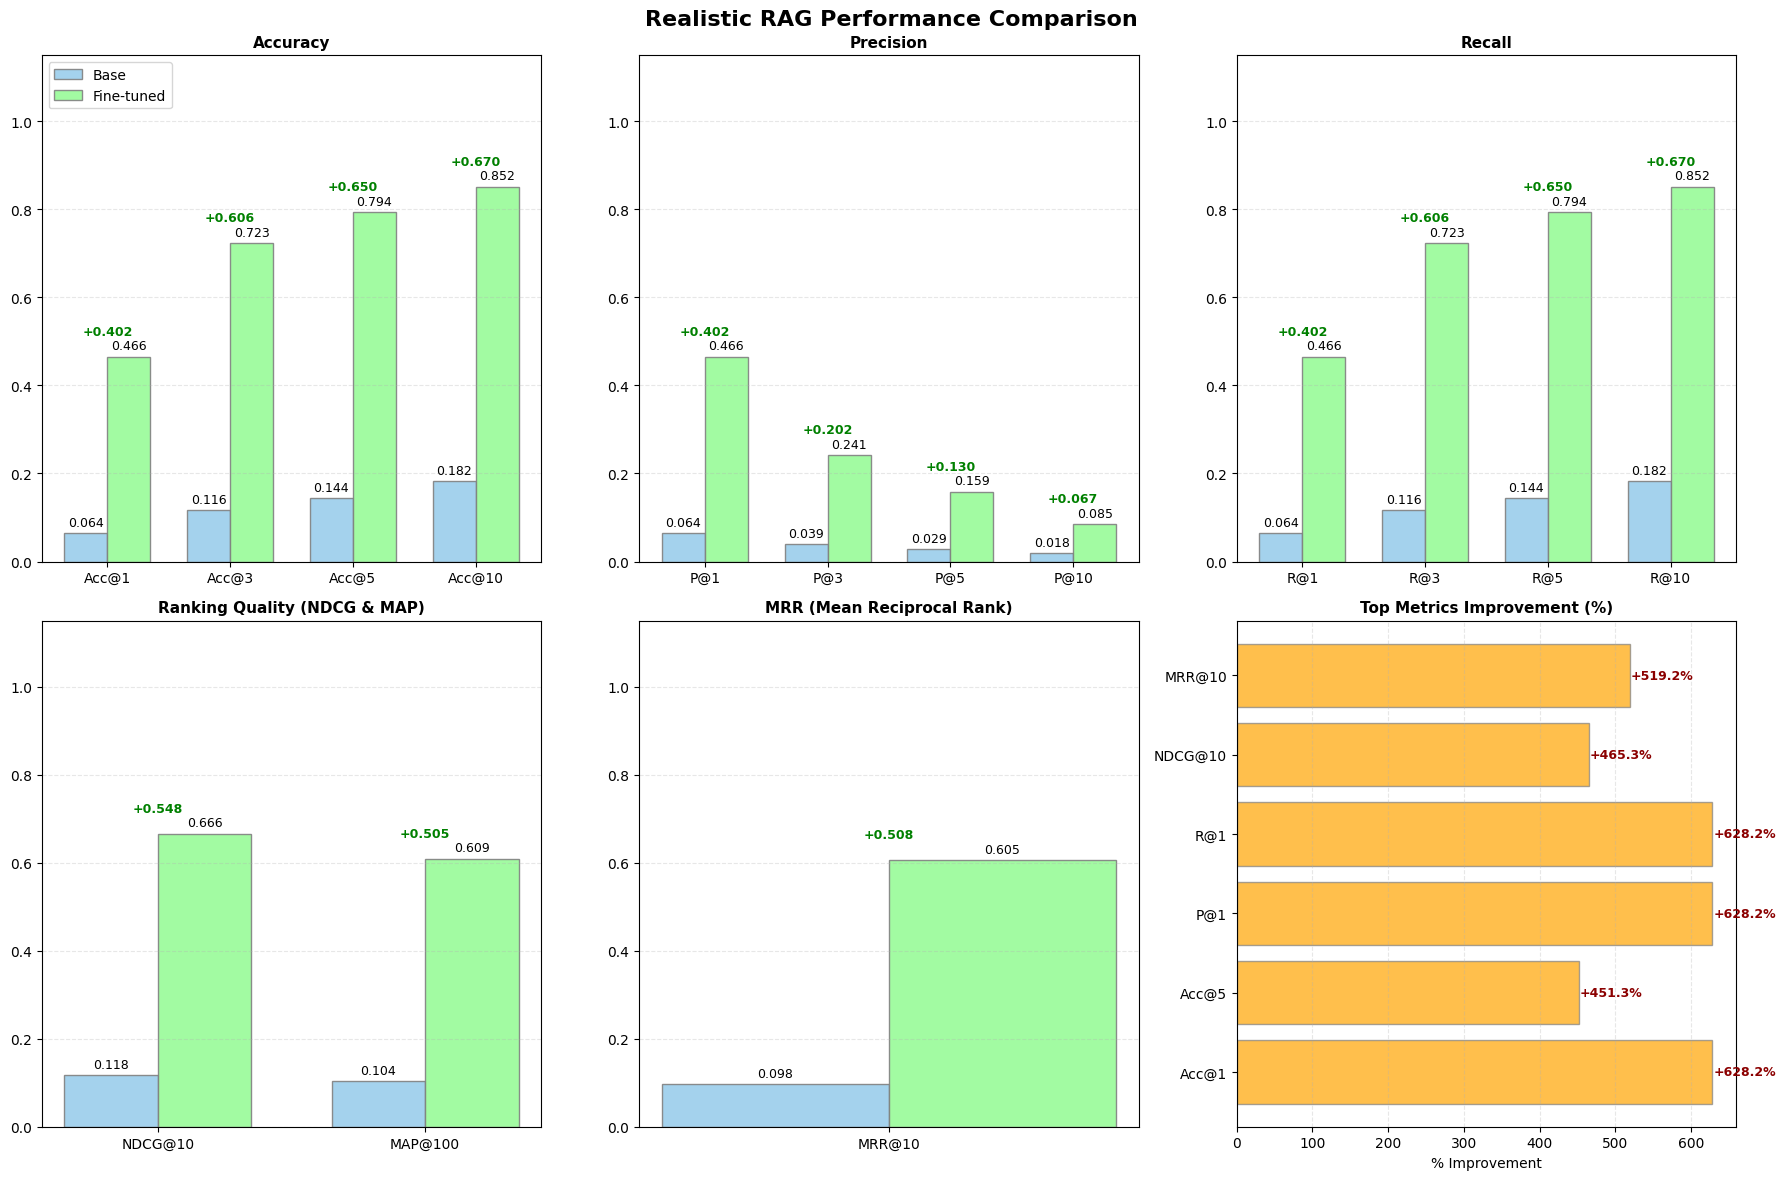

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rag_metrics_separated(res_base, res_ft, evaluator_name=""):
    """
    Vẽ 6 biểu đồ riêng biệt cho từng nhóm chỉ số:
    1. Accuracy, 2. Precision, 3. Recall, 4. Ranking, 5. MRR, 6. Tổng hợp %
    """

    # 1. Chuẩn bị dữ liệu
    prefix = f"{evaluator_name}_" if evaluator_name else ""

    # Định nghĩa dữ liệu
    metrics_data = {
        "Accuracy": [
            ("Acc@1", f"{prefix}cosine_accuracy@1"),
            ("Acc@3", f"{prefix}cosine_accuracy@3"),
            ("Acc@5", f"{prefix}cosine_accuracy@5"),
            ("Acc@10", f"{prefix}cosine_accuracy@10")
        ],
        "Precision": [
            ("P@1", f"{prefix}cosine_precision@1"),
            ("P@3", f"{prefix}cosine_precision@3"),
            ("P@5", f"{prefix}cosine_precision@5"),
            ("P@10", f"{prefix}cosine_precision@10")
        ],
        "Recall": [
            ("R@1", f"{prefix}cosine_recall@1"),
            ("R@3", f"{prefix}cosine_recall@3"),
            ("R@5", f"{prefix}cosine_recall@5"),
            ("R@10", f"{prefix}cosine_recall@10")
        ],
        "Ranking Quality (NDCG & MAP)": [
            ("NDCG@10", f"{prefix}cosine_ndcg@10"),
            ("MAP@100", f"{prefix}cosine_map@100")
        ],
        "MRR (Mean Reciprocal Rank)": [
            ("MRR@10", f"{prefix}cosine_mrr@10")
        ]
    }

    def get_val(res, key):
        return res.get(key, 0.0)

    color_base = '#9ACEEB'  # Xanh dương nhạt
    color_ft = '#98FB98'    # Xanh lá nhạt

    # 2. Thiết lập khung hình: 2 hàng, 3 cột = 6 biểu đồ
    # Kích thước lớn  để các chữ không bị đè lên nhau
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Realistic RAG Performance Comparison ', fontsize=16, fontweight='bold')

    ax_list = axes.flatten()

    # 3. VÒNG LẶP VẼ 5 NHÓM CHỈ SỐ ĐẦU TIÊN
    all_keys_flat = [] # Lưu lại để dùng cho biểu đồ tổng hợp cuối cùng

    for i, (title, keys) in enumerate(metrics_data.items()):
        ax = ax_list[i]
        all_keys_flat.extend(keys) # Gom key lại

        labels = [k[0] for k in keys]
        base_vals = [get_val(res_base, k[1]) for k in keys]
        ft_vals = [get_val(res_ft, k[1]) for k in keys]

        x = np.arange(len(labels))
        width = 0.35

        # Vẽ cột
        rects1 = ax.bar(x - width/2, base_vals, width, label='Base', color=color_base, edgecolor='grey', alpha=0.9)
        rects2 = ax.bar(x + width/2, ft_vals, width, label='Fine-tuned', color=color_ft, edgecolor='grey', alpha=0.9)

        # Trang trí
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1.15)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if i == 0: ax.legend(loc='upper left')

        # Hàm ghi số liệu
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9)

        autolabel(rects1)
        autolabel(rects2)

        # Ghi Delta (Mức tăng)
        for j in range(len(labels)):
            improvement = ft_vals[j] - base_vals[j]
            if abs(improvement) > 0.001:
                color = 'green' if improvement > 0 else 'red'
                sign = '+' if improvement > 0 else ''
                ax.text(j, max(base_vals[j], ft_vals[j]) + 0.05,
                        f'{sign}{improvement:.3f}',
                        ha='center', color=color, fontweight='bold', fontsize=9)

    # 4. BIỂU ĐỒ THỨ 6: TỔNG HỢP MỨC ĐỘ CẢI THIỆN (%)
    ax_summary = ax_list[5] # Vị trí cuối cùng (góc dưới phải)

    # Chọn lọc các chỉ số quan trọng để hiển thị ở bảng tổng hợp (tránh quá dày)
    # Lấy đại diện: Acc@1, Acc@5, P@1, R@1, NDCG@10, MRR@10
    summary_keys = [
        ("Acc@1", f"{prefix}cosine_accuracy@1"),
        ("Acc@5", f"{prefix}cosine_accuracy@5"),
        ("P@1", f"{prefix}cosine_precision@1"),
        ("R@1", f"{prefix}cosine_recall@1"),
        ("NDCG@10", f"{prefix}cosine_ndcg@10"),
        ("MRR@10", f"{prefix}cosine_mrr@10")
    ]

    labels_sum = [k[0] for k in summary_keys]
    pct_changes = []

    for _, key_full in summary_keys:
        b = get_val(res_base, key_full)
        f = get_val(res_ft, key_full)
        if b > 0:
            pct = ((f - b) / b) * 100
        else:
            pct = 0
        pct_changes.append(pct)

    y_pos = np.arange(len(labels_sum))
    # Đảo ngược thứ tự để Acc@1 nằm trên cùng
    ax_summary.barh(y_pos, pct_changes, color='orange', edgecolor='grey', alpha=0.7)
    ax_summary.set_yticks(y_pos)
    ax_summary.set_yticklabels(labels_sum)
    ax_summary.set_xlabel('% Improvement')
    ax_summary.set_title('Top Metrics Improvement (%)', fontsize=11, fontweight='bold')
    ax_summary.grid(axis='x', linestyle='--', alpha=0.3)
    # Ghi số %
    for i, v in enumerate(pct_changes):
        ax_summary.text(v + (1 if v>=0 else -5), i, f"{v:+.1f}%", va='center', fontweight='bold', color='darkred', fontsize=9)

    plt.tight_layout()
    plt.show()
# ===== GỌI HÀM =====
eval_name = ir_eval.name if hasattr(ir_eval, 'name') else ""
plot_rag_metrics_separated(res_base, res_ft, eval_name)

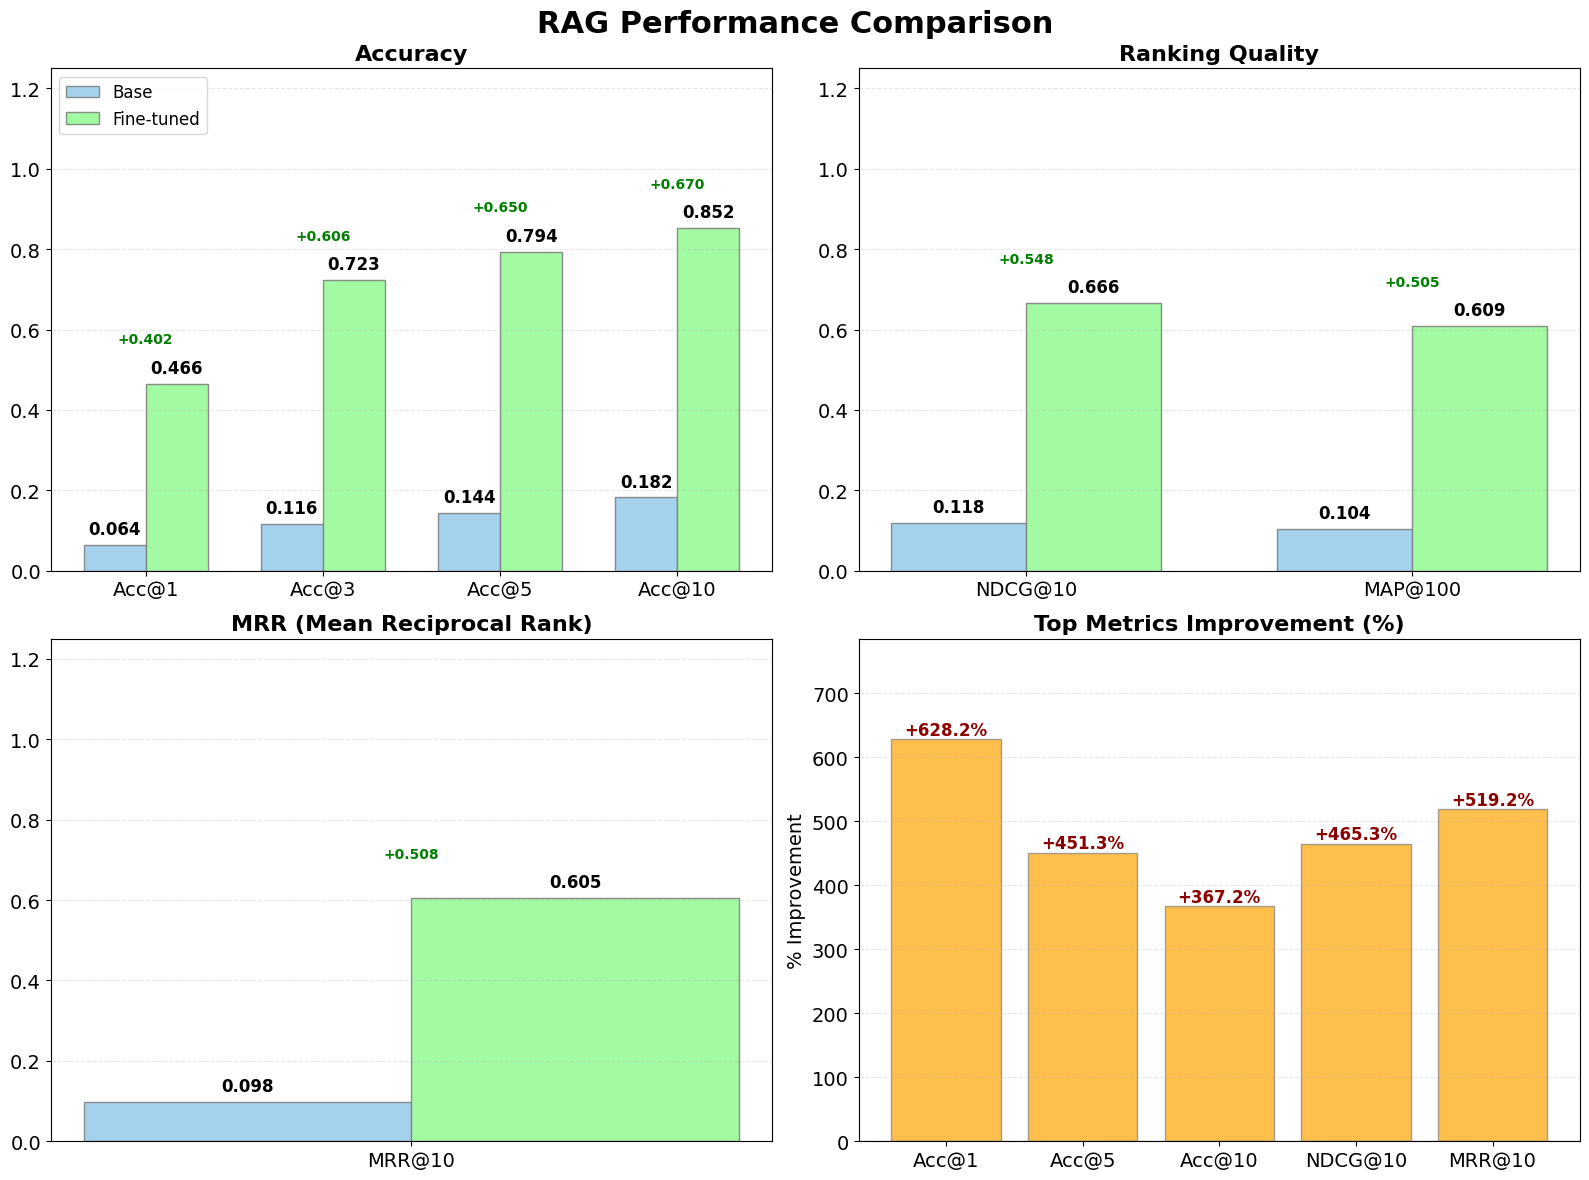

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rag_metrics_final(res_base, res_ft, evaluator_name=""):
    """
    Phiên bản Fix lỗi: Loại bỏ khoảng trắng thừa ở dưới biểu đồ cột.
    """

    # ==========================================
    # 🔴 CẤU HÌNH CỠ CHỮ
    # ==========================================
    FONT_VAL_ON_BAR = 12
    FONT_AXIS_XY    = 14
    FONT_TITLE      = 16
    FONT_DELTA      = 10
    FONT_LEGEND     = 12
    # ==========================================

    # 1. Chuẩn bị dữ liệu
    prefix = f"{evaluator_name}_" if evaluator_name else ""

    def get_val(res, key):
        return res.get(key, 0.0)

    metrics_data = {
        "Accuracy": [
            ("Acc@1", f"{prefix}cosine_accuracy@1"),
            ("Acc@3", f"{prefix}cosine_accuracy@3"),
            ("Acc@5", f"{prefix}cosine_accuracy@5"),
            ("Acc@10", f"{prefix}cosine_accuracy@10")
        ],
        "Ranking Quality": [
            ("NDCG@10", f"{prefix}cosine_ndcg@10"),
            ("MAP@100", f"{prefix}cosine_map@100")
        ],
        "MRR (Mean Reciprocal Rank)": [
            ("MRR@10", f"{prefix}cosine_mrr@10")
        ]
    }

    color_base = '#9ACEEB'
    color_ft = '#98FB98'

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'RAG Performance Comparison', fontsize=22, fontweight='bold')

    ax_list = axes.flatten()

    # 3. VÒNG LẶP VẼ 3 BIỂU ĐỒ ĐẦU TIÊN
    for i, (title, keys) in enumerate(metrics_data.items()):
        ax = ax_list[i]

        labels = [k[0] for k in keys]
        base_vals = [get_val(res_base, k[1]) for k in keys]
        ft_vals = [get_val(res_ft, k[1]) for k in keys]

        x = np.arange(len(labels))
        width = 0.35

        rects1 = ax.bar(x - width/2, base_vals, width, label='Base', color=color_base, edgecolor='grey', alpha=0.9)
        rects2 = ax.bar(x + width/2, ft_vals, width, label='Fine-tuned', color=color_ft, edgecolor='grey', alpha=0.9)

        ax.set_title(title, fontsize=FONT_TITLE, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1.25)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=FONT_AXIS_XY)

        if i == 0: ax.legend(loc='upper left', fontsize=FONT_LEGEND)

        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 5), textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=FONT_VAL_ON_BAR, fontweight='bold')
        autolabel(rects1)
        autolabel(rects2)

        for j in range(len(labels)):
            diff = ft_vals[j] - base_vals[j]
            if abs(diff) > 0.0001:
                color = 'green' if diff > 0 else 'red'
                sign = '+' if diff > 0 else ''
                ax.text(j, max(base_vals[j], ft_vals[j]) + 0.1,
                        f'{sign}{diff:.3f}', ha='center', color=color, fontweight='bold', fontsize=FONT_DELTA)

    # 4. BIỂU ĐỒ THỨ 4: TỔNG HỢP (ĐÃ SỬA LỖI KHOẢNG TRẮNG)
    ax_summary = ax_list[3]
    summary_keys = [
        ("Acc@1", f"{prefix}cosine_accuracy@1"),
        ("Acc@5", f"{prefix}cosine_accuracy@5"),
        ("Acc@10", f"{prefix}cosine_accuracy@10"),
        ("NDCG@10", f"{prefix}cosine_ndcg@10"),
        ("MRR@10", f"{prefix}cosine_mrr@10")
    ]
    labels_sum = [k[0] for k in summary_keys]
    pct_changes = []

    for _, key_full in summary_keys:
        b = get_val(res_base, key_full)
        f = get_val(res_ft, key_full)
        pct = ((f - b) / b) * 100 if b > 0 else 0
        pct_changes.append(pct)

    # Vẽ cột
    x_pos = np.arange(len(labels_sum))
    ax_summary.bar(x_pos, pct_changes, color='orange', edgecolor='grey', alpha=0.7)

    ax_summary.set_xticks(x_pos)
    ax_summary.set_xticklabels(labels_sum)
    ax_summary.set_title('Top Metrics Improvement (%)', fontsize=FONT_TITLE, fontweight='bold')
    ax_summary.set_ylabel('% Improvement', fontsize=FONT_AXIS_XY)
    ax_summary.tick_params(axis='both', labelsize=FONT_AXIS_XY)
    ax_summary.grid(axis='y', linestyle='--', alpha=0.3)
    ax_summary.axhline(0, color='black', linewidth=0.8)

    # Ghi số %
    for i, v in enumerate(pct_changes):
        offset = 0.5 if v >= 0 else -0.5
        va_align = 'bottom' if v >= 0 else 'top'
        color_text = 'darkred' if v >= 0 else 'blue'

        ax_summary.text(i, v + offset, f"{v:+.1f}%",
                        ha='center', va=va_align,
                        fontweight='bold', color=color_text, fontsize=FONT_VAL_ON_BAR)

    if pct_changes:
        max_val = max(pct_changes) if pct_changes else 0
        min_val = min(pct_changes) if pct_changes else 0

        # Nếu có số âm: Nới rộng cả trên và dưới
        if min_val < 0:
            limit_range = max(max_val, abs(min_val)) + 5
            ax_summary.set_ylim(-limit_range, limit_range)
        else:
            # Nếu toàn số dương: Bắt đầu từ 0 (Hết khoảng trắng thừa)
            ax_summary.set_ylim(0, max_val * 1.25) # Nhân 1.25 để chừa chỗ cho text trên đầu cột

    plt.tight_layout()
    plt.show()

# ===== GỌI HÀM =====
plot_rag_metrics_final(res_base, res_ft, eval_name)